# 3.8.1 Inter-Patient Cosine Similarity Analysis

This notebook analyzes the cosine similarity between **different patients** to validate that same-patient temporal consistency (from 3.8) is meaningfully different.

## Research Questions:
1. What is the distribution of cosine similarity between different patients?
2. Are same-patient similarities significantly higher than different-patient similarities?
3. Do patients with similar disease characteristics have higher inter-patient similarity?
4. What is the optimal threshold to distinguish same-patient vs different-patient scans?

## Methods:
- Calculate cosine similarity between random pairs of different patients
- Compare distributions: intra-patient (from 3.8) vs inter-patient (this notebook)
- Analyze similarity by disease severity (SBR values)
- Statistical testing to validate discriminability

## Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import cosine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import combinations
import random

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.1 Define Constants

In [2]:
# Feature columns
FEATURE_COLS = [f'latent_{i}' for i in range(256)]
TARGETS = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

# Number of random patient pairs to sample (to avoid computing all pairs)
N_RANDOM_PAIRS = 50000

print(f"Features: {len(FEATURE_COLS)}")
print(f"Targets: {TARGETS}")
print(f"Random pairs to sample: {N_RANDOM_PAIRS:,}")

Features: 256
Targets: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']
Random pairs to sample: 50,000


### 1.2 Load Data

In [3]:
# Load merged clinical data
df_merged = pd.read_csv('output/merged_data.csv')

# Load latent vectors
latent_file = 'output/Experiments/LatentVectorAnalysis/train_latent_vectors_with_patno.csv'
df_latent = pd.read_csv(latent_file)

print(f"Merged clinical data: {df_merged.shape}")
print(f"Latent vectors: {df_latent.shape}")

# Merge datasets
df_latent_clean = df_latent.dropna(subset=['PATNO']).copy()
df_combined = pd.merge(df_latent_clean, df_merged, on='PATNO', how='inner')

print(f"Combined dataset: {df_combined.shape}")
print(f"Unique patients: {df_combined['PATNO'].nunique()}")

Merged clinical data: (41816, 42)
Latent vectors: (2340, 260)
Combined dataset: (34936, 301)
Unique patients: 1413


### 1.3 Calculate SBR PCs

In [4]:
# Calculate SBR PCs
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=0)
sbr_pcs = pca.fit_transform(sbr_scaled)
df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]
df_combined = df_with_sbr.copy()

print(f"Dataset with SBR PCs: {df_combined.shape}")

Dataset with SBR PCs: (6630, 304)


### 1.4 Load Intra-Patient Similarity Results (from 3.8)

In [5]:
# Load same-patient similarity results for comparison
df_intra_patient = pd.read_csv('output/cosine_similarity_by_patient.csv')

print(f"Intra-patient similarity data: {df_intra_patient.shape}")
print(f"\nIntra-patient cosine similarity statistics:")
print(f"  Mean: {df_intra_patient['Mean_Cosine_Similarity'].mean():.4f}")
print(f"  Std:  {df_intra_patient['Mean_Cosine_Similarity'].std():.4f}")
print(f"  Min:  {df_intra_patient['Mean_Cosine_Similarity'].min():.4f}")
print(f"  Max:  {df_intra_patient['Mean_Cosine_Similarity'].max():.4f}")

Intra-patient similarity data: (921, 13)

Intra-patient cosine similarity statistics:
  Mean: 0.9546
  Std:  0.0471
  Min:  0.7611
  Max:  1.0000


## Section 2: Inter-Patient Cosine Similarity Analysis

### 2.1 Calculate Representative Latent Vector per Patient

In [6]:
print("\n" + "="*80)
print("CALCULATING REPRESENTATIVE LATENT VECTORS PER PATIENT")
print("="*80)

# For each patient, calculate mean latent vector across all scans
patient_latent_vectors = df_combined.groupby('PATNO')[FEATURE_COLS].mean()

# Also get mean SBR values
patient_sbr = df_combined.groupby('PATNO')[['SBR_PC1', 'SBR_PC2', 'SBR_PC3']].mean()

print(f"\nNumber of patients: {len(patient_latent_vectors)}")
print(f"Latent vector shape per patient: {patient_latent_vectors.shape[1]}")
print(f"\nFirst few patients:")
print(patient_latent_vectors.head())


CALCULATING REPRESENTATIVE LATENT VECTORS PER PATIENT

Number of patients: 1406
Latent vector shape per patient: 256

First few patients:
       latent_0   latent_1  latent_2  latent_3  latent_4   latent_5  latent_6  \
PATNO                                                                           
3001   1.764599 -18.460634  5.368544 -3.541638  2.420709   3.883671 -0.483119   
3002  -0.723720 -25.960619  5.031964  1.492797 -1.324533  -0.412733 -0.905938   
3003  -0.309242 -17.881543 -0.778876 -7.032584 -2.615488   3.922725  1.164277   
3006  -1.465902 -16.359520  6.493479  1.633896 -3.416310   5.625621 -4.410482   
3008  -0.374489 -27.129585  1.756566  3.520888  2.661252 -10.875023  0.320028   

       latent_7  latent_8  latent_9  latent_10  latent_11  latent_12  \
PATNO                                                                  
3001  -0.572110  1.538146 -4.206560   2.405211  -0.371080   0.840766   
3002   3.467767 -3.361440 -3.190675  -4.783760   3.448401   1.643135   
3003 

### 2.2 Sample Random Patient Pairs and Calculate Cosine Similarity

In [7]:
print("\n" + "="*80)
print("INTER-PATIENT COSINE SIMILARITY ANALYSIS")
print("="*80)

# Get list of all patients
all_patients = patient_latent_vectors.index.tolist()
n_patients = len(all_patients)

print(f"\nTotal possible patient pairs: {n_patients * (n_patients - 1) // 2:,}")
print(f"Sampling {N_RANDOM_PAIRS:,} random pairs...")

# Sample random pairs
inter_patient_similarities = []

for _ in range(N_RANDOM_PAIRS):
    # Randomly select two different patients
    pat1, pat2 = random.sample(all_patients, 2)
    
    # Get their latent vectors
    vec1 = patient_latent_vectors.loc[pat1].values
    vec2 = patient_latent_vectors.loc[pat2].values
    
    # Calculate cosine similarity
    cos_sim = 1 - cosine(vec1, vec2)
    
    # Get SBR values
    sbr1 = patient_sbr.loc[pat1]
    sbr2 = patient_sbr.loc[pat2]
    
    # Calculate SBR differences
    sbr_pc1_diff = abs(sbr1['SBR_PC1'] - sbr2['SBR_PC1'])
    sbr_pc2_diff = abs(sbr1['SBR_PC2'] - sbr2['SBR_PC2'])
    sbr_pc3_diff = abs(sbr1['SBR_PC3'] - sbr2['SBR_PC3'])
    
    inter_patient_similarities.append({
        'Patient1': pat1,
        'Patient2': pat2,
        'Cosine_Similarity': cos_sim,
        'SBR_PC1_Diff': sbr_pc1_diff,
        'SBR_PC2_Diff': sbr_pc2_diff,
        'SBR_PC3_Diff': sbr_pc3_diff,
        'Mean_SBR_PC1': (sbr1['SBR_PC1'] + sbr2['SBR_PC1']) / 2,
        'Mean_SBR_PC2': (sbr1['SBR_PC2'] + sbr2['SBR_PC2']) / 2,
        'Mean_SBR_PC3': (sbr1['SBR_PC3'] + sbr2['SBR_PC3']) / 2
    })

df_inter_patient = pd.DataFrame(inter_patient_similarities)

print(f"\nInter-patient similarity pairs calculated: {len(df_inter_patient):,}")
print(f"\nInter-Patient Cosine Similarity Statistics:")
print(f"  Mean: {df_inter_patient['Cosine_Similarity'].mean():.4f}")
print(f"  Std:  {df_inter_patient['Cosine_Similarity'].std():.4f}")
print(f"  Min:  {df_inter_patient['Cosine_Similarity'].min():.4f}")
print(f"  Max:  {df_inter_patient['Cosine_Similarity'].max():.4f}")
print(f"  Median: {df_inter_patient['Cosine_Similarity'].median():.4f}")


INTER-PATIENT COSINE SIMILARITY ANALYSIS

Total possible patient pairs: 987,715
Sampling 50,000 random pairs...

Inter-patient similarity pairs calculated: 50,000

Inter-Patient Cosine Similarity Statistics:
  Mean: 0.7734
  Std:  0.0749
  Min:  0.3031
  Max:  0.9505
  Median: 0.7846


### 2.3 Compare Intra-Patient vs Inter-Patient Similarities

In [8]:
print("\n" + "="*80)
print("COMPARISON: INTRA-PATIENT vs INTER-PATIENT SIMILARITIES")
print("="*80)

intra_mean = df_intra_patient['Mean_Cosine_Similarity'].mean()
inter_mean = df_inter_patient['Cosine_Similarity'].mean()

print(f"\nIntra-Patient (Same Patient, Different Scans):")
print(f"  Mean: {intra_mean:.4f}")
print(f"  Std:  {df_intra_patient['Mean_Cosine_Similarity'].std():.4f}")

print(f"\nInter-Patient (Different Patients):")
print(f"  Mean: {inter_mean:.4f}")
print(f"  Std:  {df_inter_patient['Cosine_Similarity'].std():.4f}")

print(f"\nDifference:")
print(f"  Δ Mean: {intra_mean - inter_mean:.4f}")
print(f"  Ratio: {intra_mean / inter_mean:.4f}x")

# Statistical test
t_stat, p_val = stats.ttest_ind(
    df_intra_patient['Mean_Cosine_Similarity'],
    df_inter_patient['Cosine_Similarity']
)

print(f"\nStatistical Test (Independent t-test):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_val:.4e}")

if p_val < 0.001:
    print(f"  → Highly significant difference (p<0.001)")
elif p_val < 0.05:
    print(f"  → Significant difference (p<0.05)")
else:
    print(f"  → No significant difference (p≥0.05)")

# Effect size (Cohen's d)
pooled_std = np.sqrt(
    ((len(df_intra_patient) - 1) * df_intra_patient['Mean_Cosine_Similarity'].std()**2 +
     (len(df_inter_patient) - 1) * df_inter_patient['Cosine_Similarity'].std()**2) /
    (len(df_intra_patient) + len(df_inter_patient) - 2)
)
cohens_d = (intra_mean - inter_mean) / pooled_std

print(f"\nEffect Size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print("  → Small effect")
elif abs(cohens_d) < 0.5:
    print("  → Medium effect")
else:
    print("  → Large effect")


COMPARISON: INTRA-PATIENT vs INTER-PATIENT SIMILARITIES

Intra-Patient (Same Patient, Different Scans):
  Mean: 0.9546
  Std:  0.0471

Inter-Patient (Different Patients):
  Mean: 0.7734
  Std:  0.0749

Difference:
  Δ Mean: 0.1812
  Ratio: 1.2343x

Statistical Test (Independent t-test):
  t-statistic: 73.1444
  p-value: 0.0000e+00
  → Highly significant difference (p<0.001)

Effect Size (Cohen's d): 2.4323
  → Large effect


### 2.4 Highest and Lowest Inter-Patient Similarities

In [9]:
print("\n" + "="*80)
print("EXTREME INTER-PATIENT SIMILARITIES")
print("="*80)

print(f"\nTop 10 Most Similar Patient Pairs (Highest Cosine Similarity):")
print(df_inter_patient.nlargest(10, 'Cosine_Similarity')[[
    'Patient1', 'Patient2', 'Cosine_Similarity', 'SBR_PC1_Diff'
]].to_string(index=False))

print(f"\nTop 10 Most Different Patient Pairs (Lowest Cosine Similarity):")
print(df_inter_patient.nsmallest(10, 'Cosine_Similarity')[[
    'Patient1', 'Patient2', 'Cosine_Similarity', 'SBR_PC1_Diff'
]].to_string(index=False))


EXTREME INTER-PATIENT SIMILARITIES

Top 10 Most Similar Patient Pairs (Highest Cosine Similarity):
 Patient1  Patient2  Cosine_Similarity  SBR_PC1_Diff
     4008      3304           0.950462      1.257481
     3470      4120           0.943431      2.821776
     4026      3470           0.943003      0.174989
     3446      3470           0.942466      0.459267
     3566      3304           0.939578      1.447136
     3587      3760           0.938175      0.705786
     3182      3226           0.937270      0.276181
     3312      4030           0.936822      0.909700
     4120      4018           0.935267      1.530473
     3470      3826           0.933678      0.428766

Top 10 Most Different Patient Pairs (Lowest Cosine Similarity):
 Patient1  Patient2  Cosine_Similarity  SBR_PC1_Diff
   222970     40754           0.303138     10.571606
   213153     40754           0.305014     12.569414
     3319     40754           0.343067     10.978835
     3972      3527           0.347221  

## Section 3: Correlation with Disease Severity

### 3.1 Similarity vs SBR Differences

In [10]:
print("\n" + "="*80)
print("CORRELATION: INTER-PATIENT SIMILARITY vs SBR DIFFERENCES")
print("="*80)

# Hypothesis: Patients with similar disease severity should have higher similarity
for target in ['SBR_PC1_Diff', 'SBR_PC2_Diff', 'SBR_PC3_Diff']:
    corr, p_val = stats.pearsonr(
        df_inter_patient['Cosine_Similarity'],
        df_inter_patient[target]
    )
    print(f"\n{target}:")
    print(f"  Pearson r: {corr:.4f}")
    print(f"  p-value: {p_val:.4e}")
    
    if p_val < 0.05:
        if corr < 0:
            print(f"  → Significant negative correlation: smaller SBR difference → higher similarity")
        else:
            print(f"  → Significant positive correlation: larger SBR difference → higher similarity")
    else:
        print(f"  → No significant correlation (p≥0.05)")


CORRELATION: INTER-PATIENT SIMILARITY vs SBR DIFFERENCES

SBR_PC1_Diff:
  Pearson r: -0.4504
  p-value: 0.0000e+00
  → Significant negative correlation: smaller SBR difference → higher similarity

SBR_PC2_Diff:
  Pearson r: -0.0504
  p-value: 1.7846e-29
  → Significant negative correlation: smaller SBR difference → higher similarity

SBR_PC3_Diff:
  Pearson r: -0.1843
  p-value: 0.0000e+00
  → Significant negative correlation: smaller SBR difference → higher similarity


### 3.2 Similarity by SBR Difference Bins

In [11]:
print("\n" + "="*80)
print("SIMILARITY BY SBR DIFFERENCE BINS")
print("="*80)

# Bin SBR differences
df_inter_patient['SBR_PC1_Diff_Bin'] = pd.cut(
    df_inter_patient['SBR_PC1_Diff'],
    bins=[0, 1, 2, 3, 100],
    labels=['0-1', '1-2', '2-3', '>3']
)

print(f"\nMean Cosine Similarity by SBR_PC1 Difference:")
for bin_label in ['0-1', '1-2', '2-3', '>3']:
    subset = df_inter_patient[df_inter_patient['SBR_PC1_Diff_Bin'] == bin_label]
    if len(subset) > 0:
        print(f"  {bin_label}: mean={subset['Cosine_Similarity'].mean():.4f}, "
              f"std={subset['Cosine_Similarity'].std():.4f}, n={len(subset)}")


SIMILARITY BY SBR DIFFERENCE BINS

Mean Cosine Similarity by SBR_PC1 Difference:
  0-1: mean=0.8041, std=0.0662, n=11046
  1-2: mean=0.7958, std=0.0676, n=9617
  2-3: mean=0.7849, std=0.0664, n=7185
  >3: mean=0.7446, std=0.0743, n=22152


## Section 4: Visualizations

### 4.1 Distribution Comparison

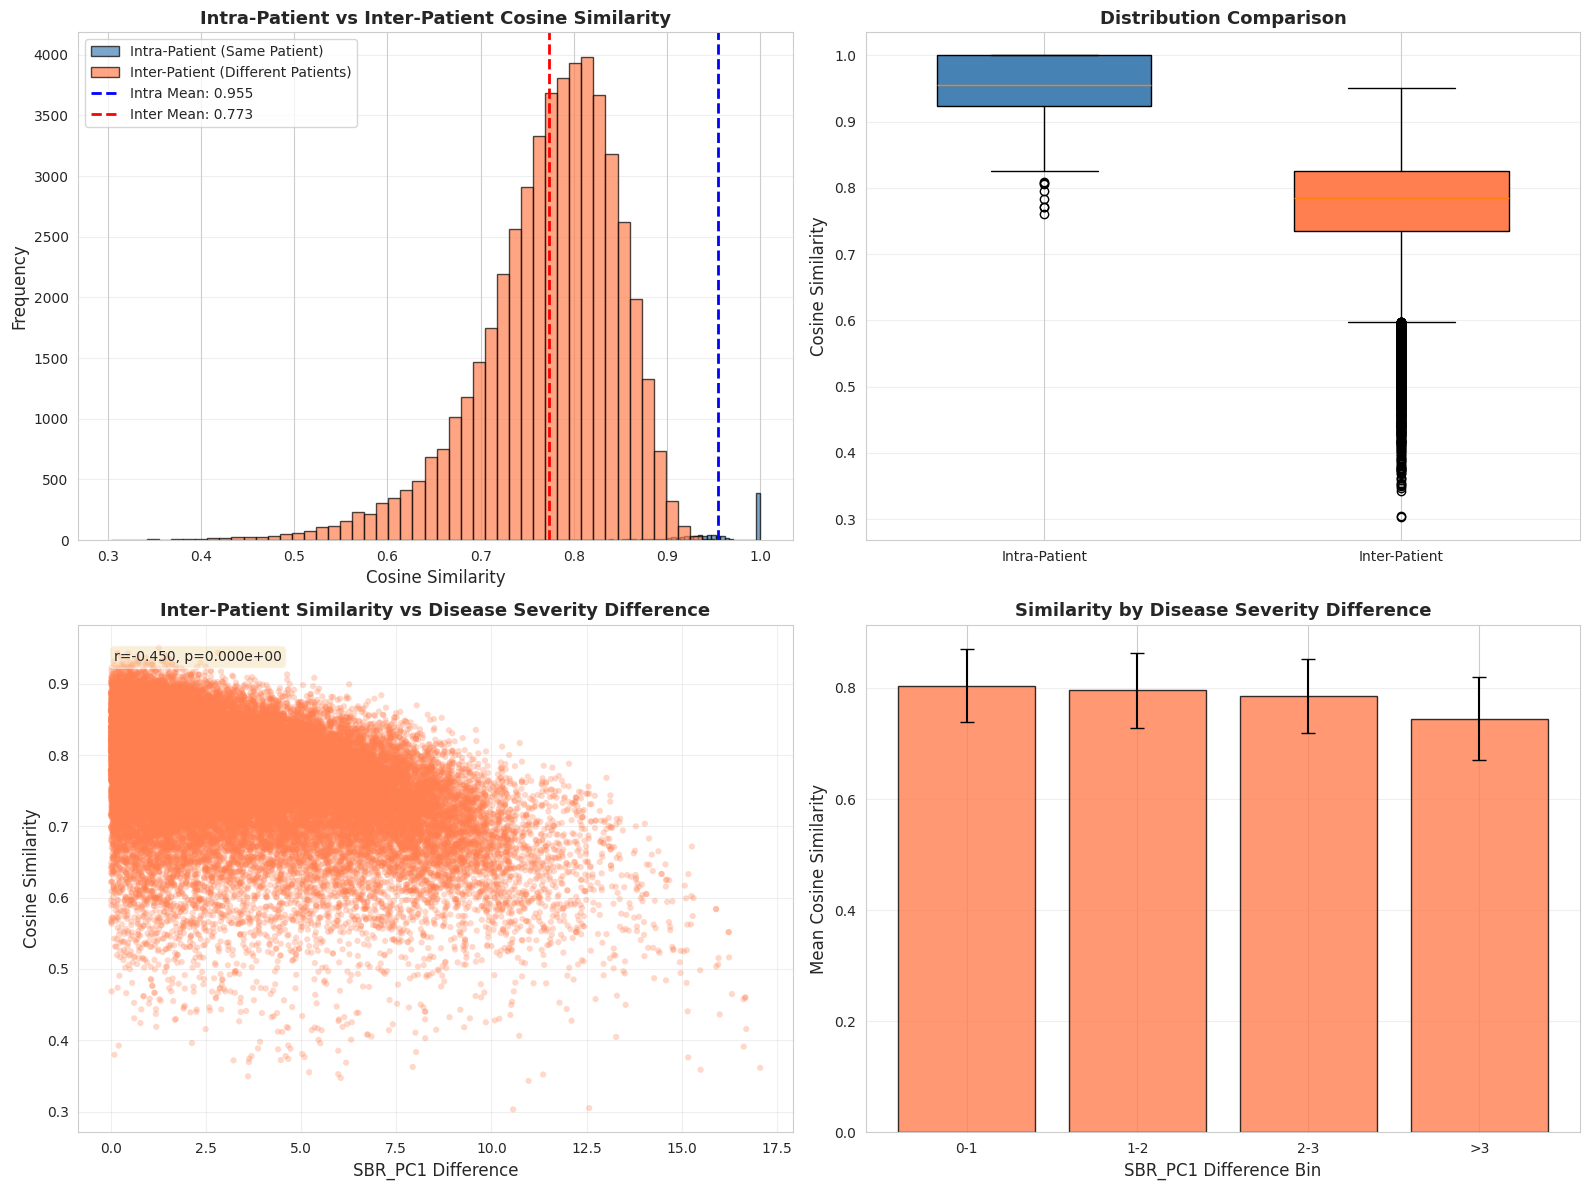

Plot saved to: output/inter_patient_cosine_similarity_analysis.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overlapping histograms
axes[0, 0].hist(df_intra_patient['Mean_Cosine_Similarity'], bins=50, alpha=0.7, 
                color='steelblue', label='Intra-Patient (Same Patient)', edgecolor='black')
axes[0, 0].hist(df_inter_patient['Cosine_Similarity'], bins=50, alpha=0.7, 
                color='coral', label='Inter-Patient (Different Patients)', edgecolor='black')
axes[0, 0].axvline(intra_mean, color='blue', linestyle='--', linewidth=2, label=f'Intra Mean: {intra_mean:.3f}')
axes[0, 0].axvline(inter_mean, color='red', linestyle='--', linewidth=2, label=f'Inter Mean: {inter_mean:.3f}')
axes[0, 0].set_xlabel('Cosine Similarity', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Intra-Patient vs Inter-Patient Cosine Similarity', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Box plot comparison
data_to_plot = [
    df_intra_patient['Mean_Cosine_Similarity'],
    df_inter_patient['Cosine_Similarity']
]
bp = axes[0, 1].boxplot(data_to_plot, labels=['Intra-Patient', 'Inter-Patient'],
                         patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[0, 1].set_ylabel('Cosine Similarity', fontsize=12)
axes[0, 1].set_title('Distribution Comparison', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Inter-patient similarity vs SBR difference
axes[1, 0].scatter(df_inter_patient['SBR_PC1_Diff'], 
                   df_inter_patient['Cosine_Similarity'],
                   alpha=0.3, s=20, color='coral', edgecolor='none')
axes[1, 0].set_xlabel('SBR_PC1 Difference', fontsize=12)
axes[1, 0].set_ylabel('Cosine Similarity', fontsize=12)
axes[1, 0].set_title('Inter-Patient Similarity vs Disease Severity Difference', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Add correlation
corr, p_val = stats.pearsonr(df_inter_patient['Cosine_Similarity'], df_inter_patient['SBR_PC1_Diff'])
axes[1, 0].text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3e}', 
                transform=axes[1, 0].transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Similarity by SBR difference bins
bin_means = []
bin_stds = []
bin_labels = ['0-1', '1-2', '2-3', '>3']
for bin_label in bin_labels:
    subset = df_inter_patient[df_inter_patient['SBR_PC1_Diff_Bin'] == bin_label]
    if len(subset) > 0:
        bin_means.append(subset['Cosine_Similarity'].mean())
        bin_stds.append(subset['Cosine_Similarity'].std())
    else:
        bin_means.append(0)
        bin_stds.append(0)

x_pos = np.arange(len(bin_labels))
axes[1, 1].bar(x_pos, bin_means, yerr=bin_stds, alpha=0.8, color='coral', 
               edgecolor='black', capsize=5)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(bin_labels)
axes[1, 1].set_xlabel('SBR_PC1 Difference Bin', fontsize=12)
axes[1, 1].set_ylabel('Mean Cosine Similarity', fontsize=12)
axes[1, 1].set_title('Similarity by Disease Severity Difference', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/inter_patient_cosine_similarity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/inter_patient_cosine_similarity_analysis.png")

### 4.2 Violin Plot for Detailed Distribution

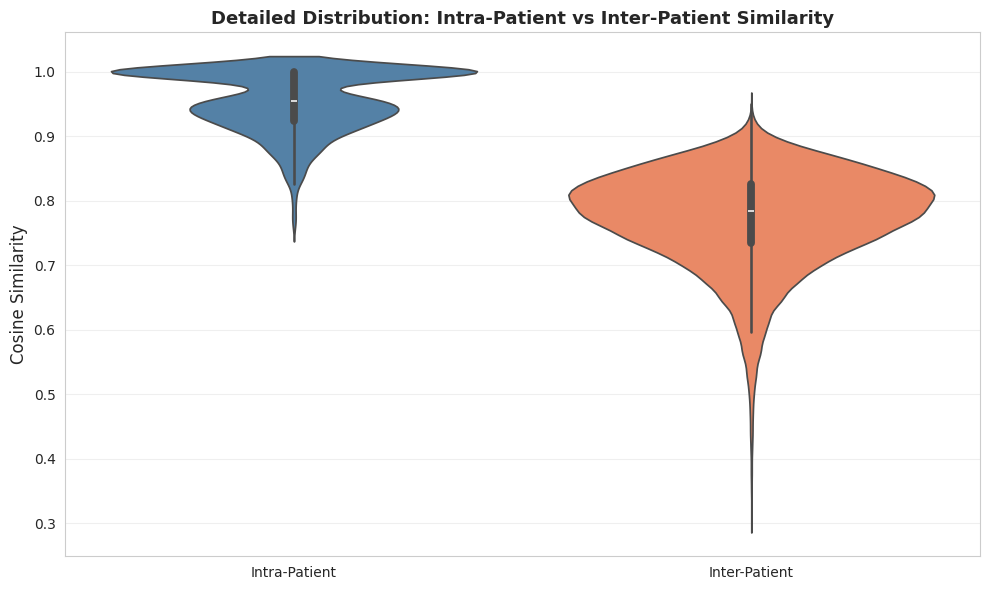

Plot saved to: output/inter_patient_violin_plot.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for violin plot
data_combined = pd.DataFrame({
    'Cosine_Similarity': list(df_intra_patient['Mean_Cosine_Similarity']) + 
                         list(df_inter_patient['Cosine_Similarity']),
    'Type': ['Intra-Patient'] * len(df_intra_patient) + 
            ['Inter-Patient'] * len(df_inter_patient)
})

sns.violinplot(data=data_combined, x='Type', y='Cosine_Similarity', 
               palette=['steelblue', 'coral'], ax=ax)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_xlabel('')
ax.set_title('Detailed Distribution: Intra-Patient vs Inter-Patient Similarity', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/inter_patient_violin_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/inter_patient_violin_plot.png")

## Section 5: Discriminability Analysis

### 5.1 ROC-like Analysis for Threshold Selection

In [14]:
print("\n" + "="*80)
print("DISCRIMINABILITY ANALYSIS")
print("="*80)

# Find optimal threshold to distinguish intra vs inter patient
thresholds = np.linspace(0.7, 1.0, 100)
accuracies = []

for threshold in thresholds:
    # True positives: intra-patient pairs above threshold
    tp = (df_intra_patient['Mean_Cosine_Similarity'] >= threshold).sum()
    # False negatives: intra-patient pairs below threshold
    fn = (df_intra_patient['Mean_Cosine_Similarity'] < threshold).sum()
    # True negatives: inter-patient pairs below threshold
    tn = (df_inter_patient['Cosine_Similarity'] < threshold).sum()
    # False positives: inter-patient pairs above threshold
    fp = (df_inter_patient['Cosine_Similarity'] >= threshold).sum()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    accuracies.append(accuracy)

# Find optimal threshold
optimal_idx = np.argmax(accuracies)
optimal_threshold = thresholds[optimal_idx]
optimal_accuracy = accuracies[optimal_idx]

print(f"\nOptimal Threshold: {optimal_threshold:.4f}")
print(f"Accuracy at Optimal Threshold: {optimal_accuracy:.4f}")

# Calculate metrics at optimal threshold
tp = (df_intra_patient['Mean_Cosine_Similarity'] >= optimal_threshold).sum()
fn = (df_intra_patient['Mean_Cosine_Similarity'] < optimal_threshold).sum()
tn = (df_inter_patient['Cosine_Similarity'] < optimal_threshold).sum()
fp = (df_inter_patient['Cosine_Similarity'] >= optimal_threshold).sum()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"\nPerformance Metrics:")
print(f"  Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"  Specificity (True Negative Rate): {specificity:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  F1-Score: {2 * (precision * sensitivity) / (precision + sensitivity):.4f}")


DISCRIMINABILITY ANALYSIS

Optimal Threshold: 0.9182
Accuracy at Optimal Threshold: 0.9948

Performance Metrics:
  Sensitivity (True Positive Rate): 0.7948
  Specificity (True Negative Rate): 0.9985
  Precision: 0.9048
  F1-Score: 0.8462


### 5.2 Threshold Analysis Plot

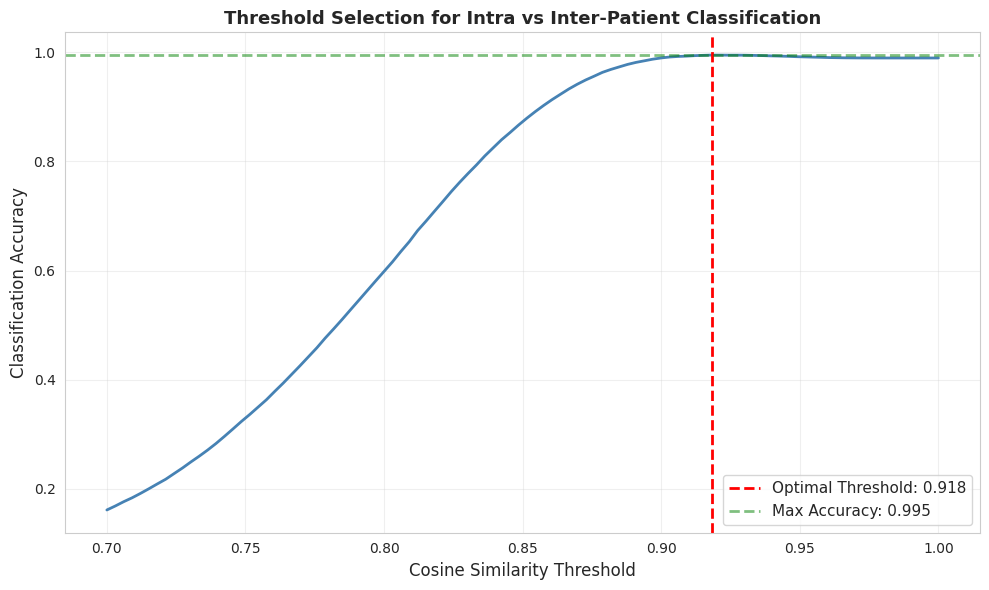

Plot saved to: output/threshold_analysis.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(thresholds, accuracies, linewidth=2, color='steelblue')
ax.axvline(optimal_threshold, color='red', linestyle='--', linewidth=2, 
           label=f'Optimal Threshold: {optimal_threshold:.3f}')
ax.axhline(optimal_accuracy, color='green', linestyle='--', linewidth=2, alpha=0.5,
           label=f'Max Accuracy: {optimal_accuracy:.3f}')
ax.set_xlabel('Cosine Similarity Threshold', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_title('Threshold Selection for Intra vs Inter-Patient Classification', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/threshold_analysis.png")

## Section 6: Save Results

In [16]:
output_dir = Path('output')

# Save inter-patient similarity results
df_inter_patient.to_csv(output_dir / 'inter_patient_cosine_similarity.csv', index=False)

# Save summary statistics
summary_stats = pd.DataFrame({
    'Metric': ['Mean', 'Std', 'Min', 'Max', 'Median'],
    'Intra_Patient': [
        df_intra_patient['Mean_Cosine_Similarity'].mean(),
        df_intra_patient['Mean_Cosine_Similarity'].std(),
        df_intra_patient['Mean_Cosine_Similarity'].min(),
        df_intra_patient['Mean_Cosine_Similarity'].max(),
        df_intra_patient['Mean_Cosine_Similarity'].median()
    ],
    'Inter_Patient': [
        df_inter_patient['Cosine_Similarity'].mean(),
        df_inter_patient['Cosine_Similarity'].std(),
        df_inter_patient['Cosine_Similarity'].min(),
        df_inter_patient['Cosine_Similarity'].max(),
        df_inter_patient['Cosine_Similarity'].median()
    ]
})
summary_stats.to_csv(output_dir / 'similarity_comparison_summary.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'inter_patient_cosine_similarity.csv'}")
print(f"  - {output_dir / 'similarity_comparison_summary.csv'}")

print(f"\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nKey Findings:")
print(f"  1. Intra-patient mean similarity: {intra_mean:.4f}")
print(f"  2. Inter-patient mean similarity: {inter_mean:.4f}")
print(f"  3. Difference: {intra_mean - inter_mean:.4f}")
print(f"  4. Statistical significance: p={p_val:.4e}")
print(f"  5. Effect size (Cohen's d): {cohens_d:.4f}")
print(f"  6. Optimal classification threshold: {optimal_threshold:.4f}")
print(f"  7. Classification accuracy: {optimal_accuracy:.4f}")

Results saved to:
  - output/inter_patient_cosine_similarity.csv
  - output/similarity_comparison_summary.csv

ANALYSIS COMPLETE

Key Findings:
  1. Intra-patient mean similarity: 0.9546
  2. Inter-patient mean similarity: 0.7734
  3. Difference: 0.1812
  4. Statistical significance: p=0.0000e+00
  5. Effect size (Cohen's d): 2.4323
  6. Optimal classification threshold: 0.9182
  7. Classification accuracy: 0.9948
